In [1]:
#Basic import 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
#Modelling
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import recall_score,classification_report, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

**Load Train And Test Data**

In [17]:
DataFrame_1=pd.read_csv("fraudTrain.csv")#Traning Dataset
DataFrame_2=pd.read_csv("fraudTest.csv")#Testing Dataset

In [19]:
#Traning Dataset 
DataFrame_1.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [20]:
#Testing Dataset
DataFrame_2.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


## Unnecessary columns drop-We can drop columns of train data and test data

####Dropping unnecessary columns, also known as feature selection, is an important step in machine learning. Raw datasets often contain noisy, redundant, or irrelevant features that do not contribute to the prediction process. Removing such columns helps improve model performance, reduces complexity, decreases training time, and prevents overfitting. By selecting only the most relevant features, the model becomes more efficient, accurate, and reliable.
##**So We can Drop this Columns**
    'Unnamed: 0',   # index column
    'trans_num',    # unique transaction id
    'cc_num',       # credit card number (identifier)
    'first',        # customer name (not useful)
    'last',         # customer name (not useful)
    'street',       # too specific location
    'city',         # high cardinality noise
    'zip'           # mostly identifier type
    'merchant'      #Too many unique values (High Cardinality)
    'job','dob'     #not useful

In [21]:
#Traning Dataset
print("DataFrame_1_Train columns:", DataFrame_1.columns)
#Testing Dataset
print("DataFrame_2_Test columns:", DataFrame_2.columns)

DataFrame_1_Train columns: Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')
DataFrame_2_Test columns: Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')


## Drop_Columns:

In [23]:
drop_cols = ['Unnamed: 0','cc_num','first','last','street','city','state','zip',
 'job','dob','trans_num','unix_time','merchant']
print(drop_cols)

['Unnamed: 0', 'cc_num', 'first', 'last', 'street', 'city', 'state', 'zip', 'job', 'dob', 'trans_num', 'unix_time', 'merchant']


In [24]:
#Tranining Dataset
DataFrame_1 = DataFrame_1.drop(drop_cols,axis=1)
print(DataFrame_1)

        trans_date_trans_time       category     amt gender      lat  \
0         2019-01-01 00:00:18       misc_net    4.97      F  36.0788   
1         2019-01-01 00:00:44    grocery_pos  107.23      F  48.8878   
2         2019-01-01 00:00:51  entertainment  220.11      M  42.1808   
3         2019-01-01 00:01:16  gas_transport   45.00      M  46.2306   
4         2019-01-01 00:03:06       misc_pos   41.96      M  38.4207   
...                       ...            ...     ...    ...      ...   
1296670   2020-06-21 12:12:08  entertainment   15.56      M  37.7175   
1296671   2020-06-21 12:12:19    food_dining   51.70      M  39.2667   
1296672   2020-06-21 12:12:32    food_dining  105.93      M  32.9396   
1296673   2020-06-21 12:13:36    food_dining   74.90      M  43.3526   
1296674   2020-06-21 12:13:37    food_dining    4.30      M  45.8433   

             long  city_pop  merch_lat  merch_long  is_fraud  
0        -81.1781      3495  36.011293  -82.048315         0  
1       -

In [25]:
#Testing Dataset
DataFrame_2 = DataFrame_2.drop(drop_cols,axis=1)
print(DataFrame_2)

       trans_date_trans_time        category     amt gender      lat  \
0        2020-06-21 12:14:25   personal_care    2.86      M  33.9659   
1        2020-06-21 12:14:33   personal_care   29.84      F  40.3207   
2        2020-06-21 12:14:53  health_fitness   41.28      F  40.6729   
3        2020-06-21 12:15:15        misc_pos   60.05      M  28.5697   
4        2020-06-21 12:15:17          travel    3.19      M  44.2529   
...                      ...             ...     ...    ...      ...   
555714   2020-12-31 23:59:07  health_fitness   43.77      M  40.4931   
555715   2020-12-31 23:59:09       kids_pets  111.84      M  29.0393   
555716   2020-12-31 23:59:15       kids_pets   86.88      F  46.1966   
555717   2020-12-31 23:59:24          travel    7.99      M  44.6255   
555718   2020-12-31 23:59:34   entertainment   38.13      M  35.6665   

            long  city_pop  merch_lat  merch_long  is_fraud  
0       -80.9355    333497  33.986391  -81.200714         0  
1      -110

# Step-1)-Feacture Engineering

##1. Convert the Date and Time columns from string data type into numerical format in both the training and testing datasets.

##We convert date and time data into numerical format in machine learning because most algorithms cannot understand raw date or string values. Machine learning models require numerical input to identify patterns, relationships, and trends effectively.

In [26]:
#STEP 1: Time Feature Engineering
#Train Data
DataFrame_1['trans_date_trans_time'] = pd.to_datetime(DataFrame_1['trans_date_trans_time'])
#Test Data
DataFrame_2['trans_date_trans_time'] = pd.to_datetime(DataFrame_2['trans_date_trans_time'])

In [27]:
#Train Data
DataFrame_1['trans_date_trans_time'].head()

0   2019-01-01 00:00:18
1   2019-01-01 00:00:44
2   2019-01-01 00:00:51
3   2019-01-01 00:01:16
4   2019-01-01 00:03:06
Name: trans_date_trans_time, dtype: datetime64[ns]

In [28]:
#Test Data
DataFrame_2['trans_date_trans_time'].head()

0   2020-06-21 12:14:25
1   2020-06-21 12:14:33
2   2020-06-21 12:14:53
3   2020-06-21 12:15:15
4   2020-06-21 12:15:17
Name: trans_date_trans_time, dtype: datetime64[ns]

##**2)Extract features from the Date and Time columns to help the model better understand temporal patterns and relationships in the data.**

In [29]:
#Trained Data i.e DataFrame_1
DataFrame_1['hour'] = DataFrame_1['trans_date_trans_time'].dt.hour
DataFrame_1['day'] = DataFrame_1['trans_date_trans_time'].dt.day
DataFrame_1['month'] = DataFrame_1['trans_date_trans_time'].dt.month
#Test Data i.e DataFrame_2
DataFrame_2['hour'] = DataFrame_2['trans_date_trans_time'].dt.hour
DataFrame_2['day'] = DataFrame_2['trans_date_trans_time'].dt.day
DataFrame_2['month'] = DataFrame_2['trans_date_trans_time'].dt.month


##We can drop the original columns before transformation because they are no longer useful for the next steps in the process.

In [30]:
#Now Drop Original Column
DataFrame_1 = DataFrame_1.drop('trans_date_trans_time', axis=1)#train data
DataFrame_2= DataFrame_2.drop('trans_date_trans_time', axis=1)#test data

In [ ]:
DataFrame_1.head(1)#i.e updated hour,day,month columns

,category,amt,gender,lat,long,city_pop,merch_lat,merch_long,is_fraud,hour,day,month
0,misc_net,4.97,F,36.0788,-81.1781,3495,36.011293,-82.048315,0,0,1,1


##**3)Create a new feature, such as Distance, to help the model better understand the relationship and patterns in the data.**

#**we create distance feature on train and test data -**
## We create the Distance feature in both the training and testing datasets because it helps the model better understand the relationship between locations. This feature provides additional useful information that can improve the model’s ability to detect patterns and make accurate predictions. Creating the same feature in both datasets also maintains consistency during training and testing.
##**Distance feature Calculate Because [distance = customer location → merchant location]**
### ***Why We Create the Distance Feature***

The `Distance` feature is calculated using the distance between the customer’s location and the merchant’s location.

* Customer location → (`lat`, `long`)
* Merchant location → (`merch_lat`, `merch_long`)

1) The model calculates the distance between these two locations.
2) This feature is important because the model can learn transaction patterns. Usually, transactions with shorter distances are more likely to be normal (`not_fraud`), while transactions with very large distances are more likely to be fraudulent (`is_fraud`).
### Example
#### Normal Transaction
* Customer → Pune
* Merchant → Pune
* Distance → Small
#### Fraud Transaction
* Customer → Pune
* Merchant → USA or another far location
* Distance → Very Large
### Suspicious Pattern
As the distance increases, the probability of fraud also increases.
### Model Learning Example
| Distance | Fraud Status |
| -------- | ------------ |
| 2 km     | Normal       |
| 5 km     | Normal       |
| 5000 km  | Fraud        |


##**Distance Feacture Calculated Formula-**

#distance feature Calculate by using Euclidean Distance
#distance = √((x1 - x2)² + (y1 - y2)²)
#x1, y1 = customer location
#x2, y2 = merchant location
#Purpose = location fraud detect

###**Using customer vs merchant location**

In [32]:
#Train Data
DataFrame_1['distance'] = ((DataFrame_1['lat'] - DataFrame_1['merch_lat'])**2 +
                        (DataFrame_1['long'] - DataFrame_1['merch_long'])**2)**0.5

In [33]:
#Test Data
DataFrame_2['distance'] = ((DataFrame_2['lat'] - DataFrame_2['merch_lat'])**2 +
                     (DataFrame_2['long'] - DataFrame_2['merch_long'])**2)**0.5

* Changed Columns

In [34]:
#Train Data
print("DataFrame_1_changes_columns :",DataFrame_1.columns)
#Test Data
print("DataFrame_2_changes_columns :",DataFrame_2.columns)

DataFrame_1_changes_columns : Index(['category', 'amt', 'gender', 'lat', 'long', 'city_pop', 'merch_lat',
       'merch_long', 'is_fraud', 'hour', 'day', 'month', 'distance'],
      dtype='object')
DataFrame_2_changes_columns : Index(['category', 'amt', 'gender', 'lat', 'long', 'city_pop', 'merch_lat',
       'merch_long', 'is_fraud', 'hour', 'day', 'month', 'distance'],
      dtype='object')


**Rename the columns in the training and testing datasets for a better and more efficient data transformation process.**

In [35]:
#Traning Dataset
train_df = DataFrame_1
train_df.head()

,category,amt,gender,lat,long,city_pop,merch_lat,merch_long,is_fraud,hour,day,month,distance
0,misc_net,4.97,F,36.0788,-81.1781,3495,36.011293,-82.048315,0,0,1,1,0.872830
1,grocery_pos,107.23,F,48.8878,-118.2105,149,49.159047,-118.186462,0,0,1,1,0.272310
2,entertainment,220.11,M,42.1808,-112.2620,4154,43.150704,-112.154481,0,0,1,1,0.975845
3,gas_transport,45.00,M,46.2306,-112.1138,1939,47.034331,-112.561071,0,0,1,1,0.919802
4,misc_pos,41.96,M,38.4207,-79.4629,99,38.674999,-78.632459,0,0,1,1,0.868505


In [36]:
#Testing Dataset
test_df= DataFrame_2
test_df.head()

,category,amt,gender,lat,long,city_pop,merch_lat,merch_long,is_fraud,hour,day,month,distance
0,personal_care,2.86,M,33.9659,-80.9355,333497,33.986391,-81.200714,0,12,21,6,0.266004
1,personal_care,29.84,F,40.3207,-110.4360,302,39.450498,-109.960431,0,12,21,6,0.991674
2,health_fitness,41.28,F,40.6729,-73.5365,34496,40.495810,-74.196111,0,12,21,6,0.682970
3,misc_pos,60.05,M,28.5697,-80.8191,54767,28.812398,-80.883061,0,12,21,6,0.250985
4,travel,3.19,M,44.2529,-85.0170,1126,44.959148,-85.884734,0,12,21,6,1.118816


#**Feactures Transformation**

#**Feacture Transformation Steps-**

#**STEP i]: Split X and Y**
##**1) Train-Test Split**
The first step in feature transformation is the train-test split. However, in this project, the dataset already contained separate training and testing data. Therefore, there was no need to use `train_test_split()` again.

Since the dataset already had predefined train and test splits, I did not use `train_test_split()` to avoid data leakage and maintain consistency between the datasets.

In [37]:
#Train Data
X_train = train_df.drop('is_fraud',axis=1)
y_train = train_df['is_fraud']
#Test Data
X_test = test_df.drop('is_fraud',axis=1)
y_test = test_df['is_fraud']

##**Feacture Transformation- There are various Steps of feacture transformation**
## **Feature Transformation:-**
Feature transformation consists of various steps used to prepare the data for machine learning models.

### **1) Train-Test Split**

Split the dataset into training and testing data for model training and evaluation.

###**2)Missing Value Imputation**
Handle missing values by replacing them with suitable values such as mean, median, or mode.

###**3)Convert Categorical Data into Numerical Data**
Convert categorical features into numerical format so that machine learning algorithms can process them.

###**4)Feature Scaling**
Scale numerical features to bring them into a similar range and improve model performance.
### **5) Outlier Detection**
Identify and handle outliers to reduce their negative impact on the model.

In [38]:
X_train.columns

Index(['category', 'amt', 'gender', 'lat', 'long', 'city_pop', 'merch_lat',
       'merch_long', 'hour', 'day', 'month', 'distance'],
      dtype='object')

In [39]:
X_test.columns

Index(['category', 'amt', 'gender', 'lat', 'long', 'city_pop', 'merch_lat',
       'merch_long', 'hour', 'day', 'month', 'distance'],
      dtype='object')

In [40]:
y_train

0          0
1          0
2          0
3          0
4          0
          ..
1296670    0
1296671    0
1296672    0
1296673    0
1296674    0
Name: is_fraud, Length: 1296675, dtype: int64

# What we can do in Columns Transformer
1)“We can convert categorical data in both the training and testing datasets using the scikit-learn preprocessing class, i.e., OneHotEncoder.”['category','gender']
2)Feacture Scaling-There are two techniques used.
    1) Outliers are handled first, as they do not follow a normal distribution; they are right-skewed and contain extreme values. To address this, they are transformed to approximate a normal distribution using log transformation, which helps reduce skewness.
    2) The remaining columns that already follow a normal distribution are scaled using appropriate scaling techniques.
###1. **Amt and City_Pop are highly skewed** and can be handled using log transformation.
###2. **long and merch_long are negatively skewed (around -1)**, but this step is optional.
###3. **One-hot encoded columns should be ignored during scaling**, including:

   * category_*
   * gender_M
###4. **Numeric columns should be scaled only after handling skewness.**
num_cols = ['amt','lat','long','city_pop','merch_lat',
            'merch_long','hour','day','month','distance']

# Pipeline

In [65]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer
)
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Numerical Pipeline

In [66]:
num_pipeline = Pipeline([
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

In [72]:
preprocessor = ColumnTransformer([

    ('cat',
     OneHotEncoder(drop='first', sparse_output=False),
     ['category', 'gender']),

    ('num_pipeline',
     num_pipeline,
     ['amt', 'city_pop']),

    ('scale',
     StandardScaler(),
     ['amt', 'city_pop','lat', 'long',
      'merch_lat', 'merch_long',
      'hour', 'day',
      'month', 'distance'])

], remainder='passthrough')

In [89]:
from xgboost import XGBClassifier

pipeline = ImbPipeline([

    ('preprocessor', preprocessor),

    ('smote', SMOTE(random_state=42)),

    ('classifier',
     XGBClassifier(colsample_bytree=0.4,
         gamma=0.3,
         learning_rate=0.2,
         max_depth=15,
         min_child_weight=1,
         random_state=42))

])

In [90]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num_pipeline', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [91]:
y_pred = pipeline.predict(X_test)

In [92]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [93]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred))

0.9982149251690152


In [94]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.81      0.71      0.75      2145

    accuracy                           1.00    555719
   macro avg       0.90      0.85      0.88    555719
weighted avg       1.00      1.00      1.00    555719



# Plot y_test and y_pred

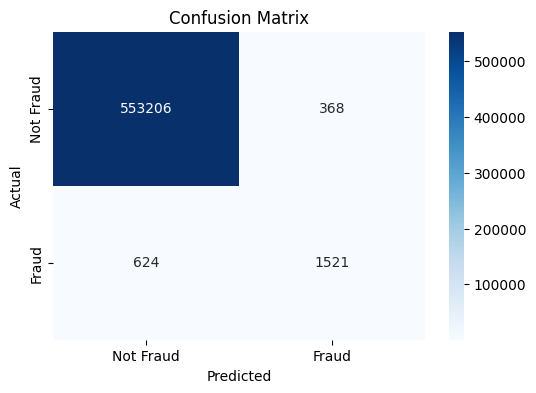

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Fraud', 'Fraud'],
    yticklabels=['Not Fraud', 'Fraud']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Actual vs Predicted Plot

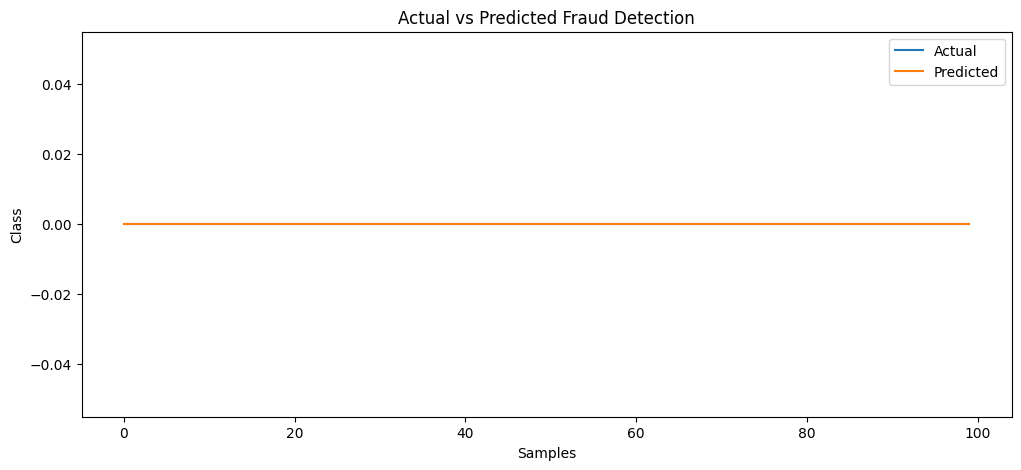

In [80]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values[:100], label='Actual')
plt.plot(y_pred[:100], label='Predicted')

plt.legend()

plt.title("Actual vs Predicted Fraud Detection")
plt.xlabel("Samples")
plt.ylabel("Class")

plt.show()

# Fraud Visualization

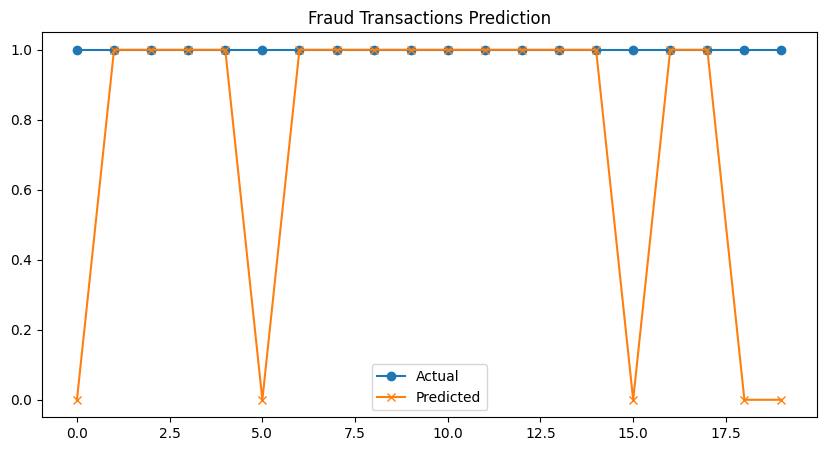

In [82]:
fraud_idx = y_test[y_test == 1].index[:20]

plt.figure(figsize=(10,5))

plt.plot(y_test.loc[fraud_idx].values,
         marker='o',
         label='Actual')

plt.plot(y_pred[fraud_idx],
         marker='x',
         label='Predicted')

plt.legend()

plt.title("Fraud Transactions Prediction")

plt.show()